In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os 
import sys
import pandas as pd
from os.path import join
from easydict import EasyDict as edict
import json
import seaborn as sns
import matplotlib.pyplot as plt
sys.path.append("/n/home12/binxuwang/Github/DiffusionAttnConsistency")
from scripts.parity_memorization_eval_cli import evaluate_experiment_memorization, compute_membership_counts

exp_names = sorted(os.listdir("/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionParityLearning"))
exp_names = [exp_name for exp_name in exp_names if "DiT" in exp_name]

/n/home12/binxuwang/Github/circuit_toolkit/circuit_toolkit/GAN_invert_utils.py:2: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import trange, tqdm


In [ ]:
exp_name = "DiT_mini_parity_N8192_D36_G4_even"
for exp_name in [
        "DiT_mini_parity_N8192_D36_G9_even",
        ]:
    mem_eval_stats_df = evaluate_experiment_memorization(exp_name, incremental=True, skip_completed=True, save_plot=False)

/n/home12/binxuwang/Github/circuit_toolkit/circuit_toolkit/GAN_invert_utils.py:2: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import trange, tqdm


Evaluating experiment: DiT_mini_parity_N8192_D36_G9_even
Parameters: 8192 samples, 36 bits per sample, 9 bits per group
Found 1471 evaluation steps: 1 to 1000000
Found existing results for 1471 steps
Incremental mode: processing 0 new steps
Starting with 1471 existing results
No new steps to process
Saved evaluation statistics to /n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionParityLearning/DiT_mini_parity_N8192_D36_G9_even/mem_eval_stats.csv


In [3]:
saveroot = "/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionParityLearning"
mem_eval_syn_df = pd.read_csv(join(saveroot, "mem_eval_synopsis.csv"))

### Demo load

In [ ]:
mem_eval_syn_df.shape

(103923, 20)

In [ ]:
mem_eval_syn_df.columns

Index(['step', 'sample_mem_num', 'sample_mem_ratio', 'bitgroup_mem_num',
       'bitgroup_mem_ratio', 'sample_num', 'group_size', 'nan_num_eps_1e-1',
       'nan_ratio_eps_1e-1', 'nan_num_eps_1e-2', 'nan_ratio_eps_1e-2',
       'pergroup_parity_num', 'pergroup_parity_acc', 'sample_corr_num',
       'sample_corr_acc', 'exp_name', 'train_sample_num', 'num_groups',
       'DiT_nlayer', 'DiT_nhead'],
      dtype='object')

In [ ]:
len(mem_eval_syn_df.exp_name.unique())

72

In [ ]:
mem_eval_syn_df.step.max()

1000000

### load and show single example

In [12]:
mem_eval_syn_df.query("step == 1000000")

,step,sample_mem_num,sample_mem_ratio,bitgroup_mem_num,bitgroup_mem_ratio,sample_num,group_size,nan_num_eps_1e-1,nan_ratio_eps_1e-1,nan_num_eps_1e-2,nan_ratio_eps_1e-2,pergroup_parity_num,pergroup_parity_acc,sample_corr_num,sample_corr_acc,exp_name,train_sample_num,num_groups,DiT_nlayer,DiT_nhead
11188,1000000,1497,0.730957,5418,0.881836,2048,12,42,0.020508,119,0.058105,5406,0.879883,1547,0.755371,DiT_S_parity_N4096_D36_G12_even,4096,3,12,6
12660,1000000,1366,0.666992,3062,0.747559,2048,18,8,0.003906,61,0.029785,3423,0.835693,1503,0.733887,DiT_S_parity_N4096_D36_G18_even,4096,2,12,6
14132,1000000,1650,0.805664,36861,0.999919,2048,2,4,0.001953,7,0.003418,36859,0.999864,2043,0.997559,DiT_S_parity_N4096_D36_G2_even,4096,18,12,6
15604,1000000,1431,0.698730,1431,0.698730,2048,36,32,0.015625,69,0.033691,1669,0.814941,1669,0.814941,DiT_S_parity_N4096_D36_G36_even,4096,1,12,6
17076,1000000,1188,0.580078,24524,0.997884,2048,3,9,0.004395,21,0.010254,24518,0.997640,1991,0.972168,DiT_S_parity_N4096_D36_G3_even,4096,12,12,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98038,1000000,77,0.037598,77,0.037598,2048,36,1,0.000488,8,0.003906,1065,0.520020,1065,0.520020,DiT_nano_parity_N4096_D36_G36_even,4096,1,3,6
99509,1000000,46,0.022461,24537,0.998413,2048,3,29,0.014160,54,0.026367,24519,0.997681,1992,0.972656,DiT_nano_parity_N4096_D36_G3_even,4096,12,3,6
100980,1000000,14,0.006836,18338,0.994900,2048,4,23,0.011230,41,0.020020,18324,0.994141,1944,0.949219,DiT_nano_parity_N4096_D36_G4_even,4096,9,3,6
102451,1000000,70,0.034180,8059,0.655843,2048,6,5,0.002441,23,0.011230,8057,0.655680,197,0.096191,DiT_nano_parity_N4096_D36_G6_even,4096,6,3,6


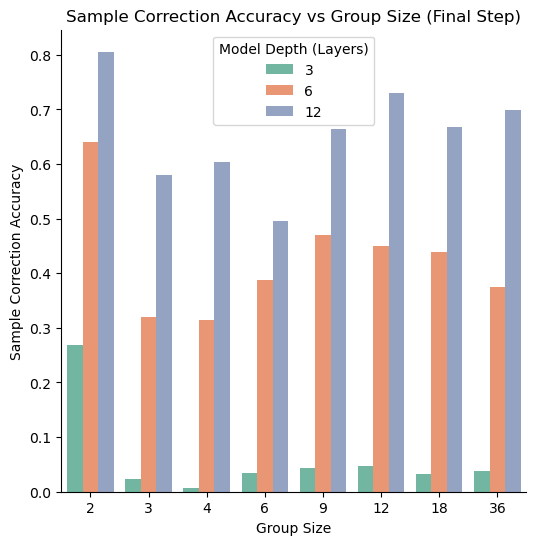

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

final_step_df = mem_eval_syn_df.query("step == 1000000 and train_sample_num == 4096")
plt.figure(figsize=(6, 6))
sns.barplot(data=final_step_df, x="group_size", y="sample_mem_ratio", hue="DiT_nlayer", palette="Set2")
plt.xlabel("Group Size")
plt.ylabel("Sample Correction Accuracy")
plt.title("Sample Correction Accuracy vs Group Size (Final Step)")
plt.legend(title="Model Depth (Layers)")
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

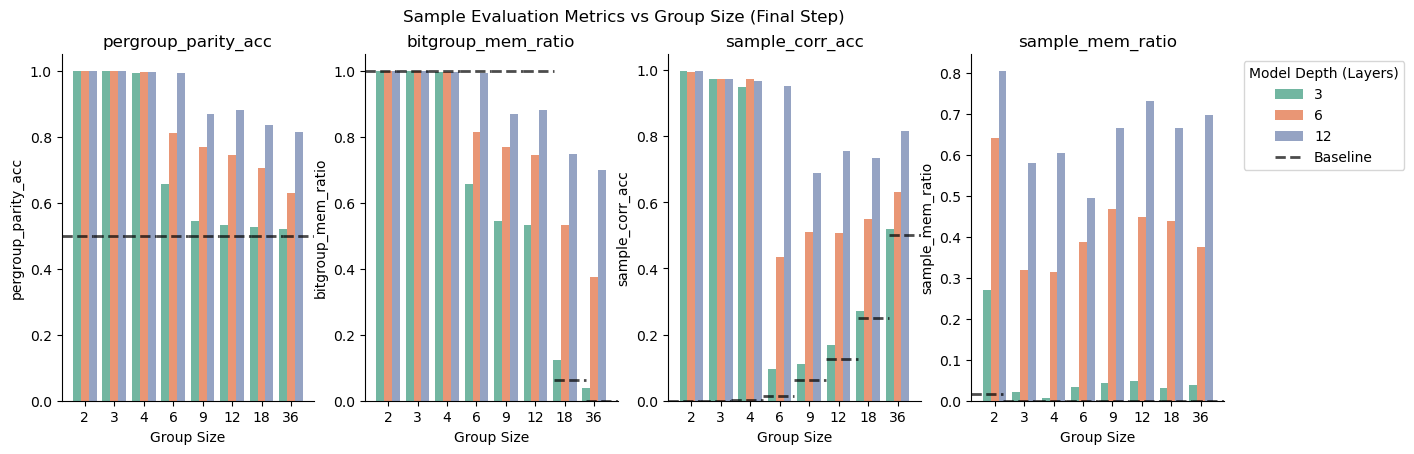

In [58]:
def pergroup_parity_acc_baseline(G, D=36):
    return (1/2)

def sample_corr_baseline(G, D=36):
    return (1/2)**(D/G)

def bitgroup_mem_ratio_baseline(G, N=4096, D=36):
    return min(1.0, N * (D//G) / (2 ** (G-1)))

def sample_mem_ratio_baseline(G, N=4096, D=36):
    return N / (2 ** (G-1)) ** (D / G)


# Define baseline dictionary mapping group size to baseline values
baseline_dict = {
    "pergroup_parity_acc": {G: pergroup_parity_acc_baseline(G) for G in [2, 3, 4, 6, 9, 12, 18, 36]},
    "bitgroup_mem_ratio": {G: bitgroup_mem_ratio_baseline(G) for G in [2, 3, 4, 6, 9, 12, 18, 36]},
    "sample_corr_acc": {G: sample_corr_baseline(G) for G in [2, 3, 4, 6, 9, 12, 18, 36]},
    "sample_mem_ratio": {G: sample_mem_ratio_baseline(G) for G in [2, 3, 4, 6, 9, 12, 18, 36]},
}

final_step_df = mem_eval_syn_df.query("step == 1000000 and train_sample_num == 4096")
plt.subplots(1, 4, figsize=(15, 4.5))
for i, metric in enumerate(["pergroup_parity_acc", "bitgroup_mem_ratio", "sample_corr_acc", "sample_mem_ratio", ]):
    plt.subplot(1, 4, i+1)
    ax = sns.barplot(data=final_step_df, x="group_size", y=metric, hue="DiT_nlayer", palette="Set2")
    
    # Add baseline dashed lines
    group_sizes = sorted(final_step_df["group_size"].unique())
    baseline_values = [baseline_dict[metric][gs] for gs in group_sizes]
    x_positions = range(len(group_sizes))
    
    # Plot flat horizontal lines for each bar position
    for j, (x_pos, baseline_val) in enumerate(zip(x_positions, baseline_values)):
        plt.axhline(y=baseline_val, xmin=x_pos/len(group_sizes), xmax=(x_pos+1)/len(group_sizes), 
                   color='k', linestyle='--', linewidth=2, alpha=0.7)
    
    # Add a legend entry for baseline
    plt.plot([], [], 'k--', linewidth=2, alpha=0.7, label='Baseline')
    
    plt.xlabel("Group Size")
    plt.ylabel(metric)
    plt.title(f"{metric}")
    if i == 3:
        plt.legend(title="Model Depth (Layers)", bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        plt.legend().remove()
plt.suptitle("Sample Evaluation Metrics vs Group Size (Final Step)")
plt.show()

### Systematic baseline plot

In [29]:
def add_baseline_lines(x_unique, baseline_dict, color='k', linestyle='--', linewidth=2, alpha=0.7, label='Baseline', ax=None):
    if ax is None:
        ax = plt.gca()
    # Add baseline dashed lines
    group_sizes = sorted(x_unique)
    baseline_values = [baseline_dict[gs] for gs in group_sizes]
    x_positions = range(len(group_sizes))
    
    # Plot flat horizontal lines for each bar position
    for j, (x_pos, baseline_val) in enumerate(zip(x_positions, baseline_values)):
        ax.hlines(y=baseline_val, xmin=x_pos-0.4, xmax=x_pos+0.4,
                   color=color, linestyle=linestyle, linewidth=linewidth, alpha=alpha, label=None)
        # plt.axhline(y=baseline_val, xmin=x_pos/len(group_sizes), xmax=(x_pos+1)/len(group_sizes), 
        # plt.axhline(y=baseline_val, xmin=x_pos-0.4, xmax=x_pos+0.4,
        #            color=color, linestyle=linestyle, linewidth=linewidth, alpha=alpha, label=None)
    
    # Add a legend entry for baseline
    ax.plot([], [], linestyle=linestyle, color=color,
        linewidth=linewidth, alpha=alpha, label=label)


In [34]:
def pergroup_parity_acc_baseline(G, D=36):
    return (1/2)

def sample_corr_baseline(G, D=36):
    return (1/2)**(D//G)

def bitgroup_mem_ratio_groundtruth_baseline(G, N=4096, D=36):
    return min(1.0, N * (D//G) / (2 ** (G-1)))

def bitgroup_mem_ratio_rand_baseline(G, N=4096, D=36):
    return min(N * (D//G), 2 ** (G-1)) / 2 ** G

def sample_mem_ratio_groundtruth_baseline(G, N=4096, D=36):
    return N / (2 ** (G-1)) ** (D // G)

def sample_mem_ratio_rand_baseline(G, N=4096, D=36):
    return N / 2 ** D

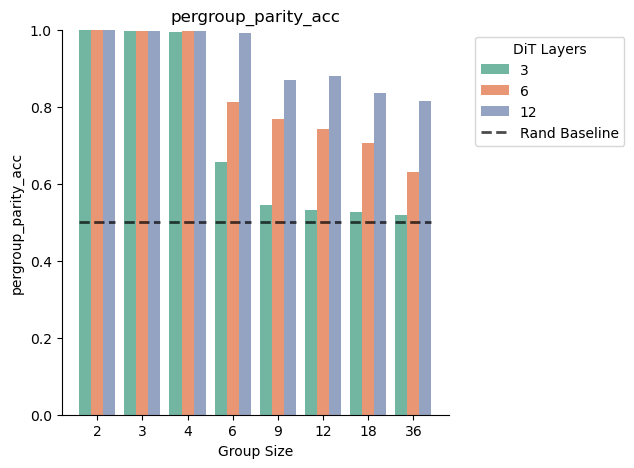

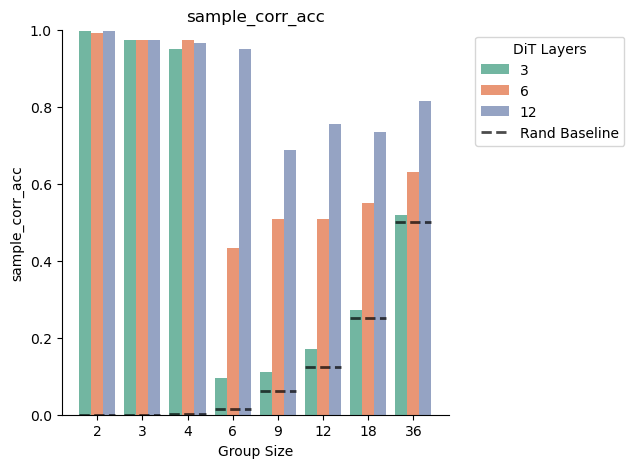

In [43]:
from circuit_toolkit.plot_utils import saveallforms
figdir = "/n/home12/binxuwang/Github/DiffusionAttnConsistency/figures/synopsis"

# Define baseline dictionary mapping group size to baseline values
baseline_dict = {
    "pergroup_parity_acc": {G: pergroup_parity_acc_baseline(G) for G in [2, 3, 4, 6, 9, 12, 18, 36]},
    # "bitgroup_mem_ratio": {G: bitgroup_mem_ratio_baseline(G) for G in [2, 3, 4, 6, 9, 12, 18, 36]},
    "sample_corr_acc": {G: sample_corr_baseline(G) for G in [2, 3, 4, 6, 9, 12, 18, 36]},
    # "sample_mem_ratio": {G: sample_mem_ratio_baseline(G) for G in [2, 3, 4, 6, 9, 12, 18, 36]},
}

final_step_df = mem_eval_syn_df.query("step == 1000000 and train_sample_num == 4096")

for i, metric in enumerate(["pergroup_parity_acc", "sample_corr_acc", ]):
    plt.figure(figsize=(5, 5))
    sns.barplot(data=final_step_df, x="group_size", y=metric, hue="DiT_nlayer", palette="Set2")
    add_baseline_lines(final_step_df.group_size.unique(), 
                       baseline_dict[metric], color='k', linestyle='--', linewidth=2, alpha=0.7, label='Rand Baseline')
    plt.ylim(0, 1)
    plt.xlabel("Group Size")
    plt.ylabel(metric)
    plt.title(f"{metric}")
    plt.legend(title="DiT Layers", bbox_to_anchor=(1.05, 1), loc='upper left')
    # plt.tight_layout()
    saveallforms(figdir, f"DiT_parity_eval_metrics_{metric}_N4096", plt.gcf())
    plt.show()


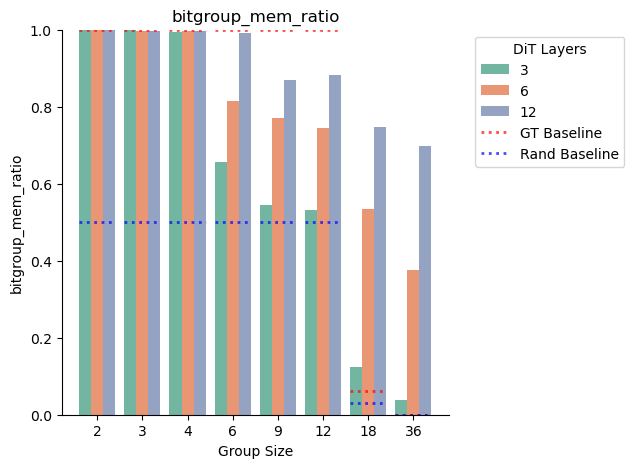

In [44]:
metric = "bitgroup_mem_ratio"
group_sizes = sorted(final_step_df.group_size.unique())
plt.figure(figsize=(5, 5))
ax = sns.barplot(data=final_step_df, x="group_size", y=metric, hue="DiT_nlayer", palette="Set2")
add_baseline_lines(group_sizes, 
                    {G: bitgroup_mem_ratio_groundtruth_baseline(G) for G in group_sizes}, 
                    color='r', linestyle=':', linewidth=2, alpha=0.7, label='GT Baseline')
add_baseline_lines(group_sizes, 
                    {G: bitgroup_mem_ratio_rand_baseline(G) for G in group_sizes}, 
                    color='b', linestyle=':', linewidth=2, alpha=0.7, label='Rand Baseline')
plt.ylim(0, 1)
plt.xlabel("Group Size")
plt.ylabel(metric)
plt.title(f"{metric}")
plt.legend(title="DiT Layers", bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
saveallforms(figdir, f"DiT_parity_eval_metrics_{metric}_N4096", plt.gcf())
plt.show()

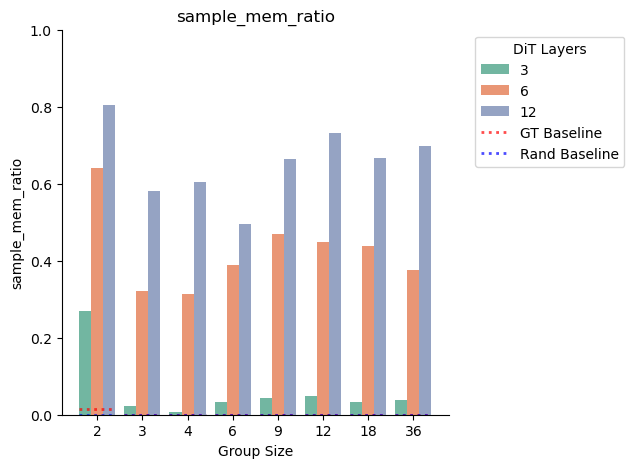

In [45]:
metric = "sample_mem_ratio"
group_sizes = sorted(final_step_df.group_size.unique())
plt.figure(figsize=(5, 5))
ax = sns.barplot(data=final_step_df, x="group_size", y=metric, hue="DiT_nlayer", palette="Set2")
add_baseline_lines(group_sizes, 
                    {G: sample_mem_ratio_groundtruth_baseline(G) for G in group_sizes}, 
                    color='r', linestyle=':', linewidth=2, alpha=0.7, label='GT Baseline')
add_baseline_lines(group_sizes, 
                    {G: sample_mem_ratio_rand_baseline(G) for G in group_sizes}, 
                    color='b', linestyle=':', linewidth=2, alpha=0.7, label='Rand Baseline')
plt.ylim(0, 1)
plt.xlabel("Group Size")
plt.ylabel(metric)
plt.title(f"{metric}")
plt.legend(title="DiT Layers", bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
saveallforms(figdir, f"DiT_parity_eval_metrics_{metric}_N4096", plt.gcf())
plt.show()

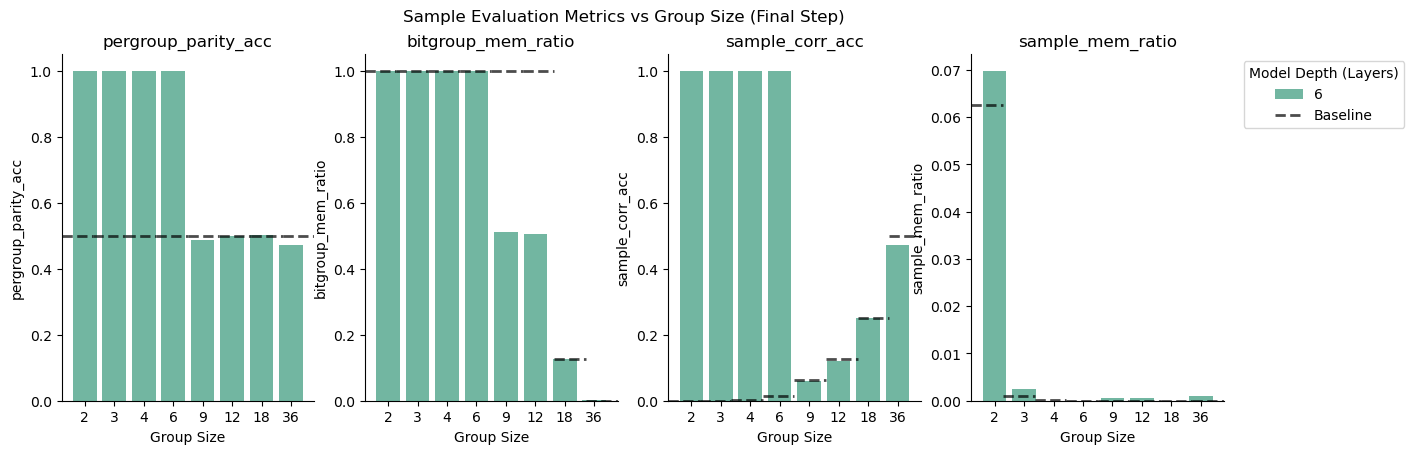

In [60]:
def pergroup_parity_acc_baseline(G, D=36):
    return (1/2)

def sample_corr_baseline(G, D=36):
    return (1/2)**(D/G)

def bitgroup_mem_ratio_baseline(G, N=4096*4, D=36):
    return min(1.0, N * (D//G) / (2 ** (G)))
    return min(1.0, N * (D//G) / (2 ** (G-1)))

def sample_mem_ratio_baseline(G, N=4096*4, D=36):
    return N / (2 ** (G-1)) ** (D / G)


# Define baseline dictionary mapping group size to baseline values
baseline_dict = {
    "pergroup_parity_acc": {G: pergroup_parity_acc_baseline(G) for G in [2, 3, 4, 6, 9, 12, 18, 36]},
    "bitgroup_mem_ratio": {G: bitgroup_mem_ratio_baseline(G) for G in [2, 3, 4, 6, 9, 12, 18, 36]},
    "sample_corr_acc": {G: sample_corr_baseline(G) for G in [2, 3, 4, 6, 9, 12, 18, 36]},
    "sample_mem_ratio": {G: sample_mem_ratio_baseline(G) for G in [2, 3, 4, 6, 9, 12, 18, 36]},
}

final_step_df = mem_eval_syn_df.query("step == 1000000 and train_sample_num == 4096*4")
plt.subplots(1, 4, figsize=(15, 4.5))
for i, metric in enumerate(["pergroup_parity_acc", "bitgroup_mem_ratio", "sample_corr_acc", "sample_mem_ratio", ]):
    plt.subplot(1, 4, i+1)
    ax = sns.barplot(data=final_step_df, x="group_size", y=metric, hue="DiT_nlayer", palette="Set2")
    
    # Add baseline dashed lines
    group_sizes = sorted(final_step_df["group_size"].unique())
    baseline_values = [baseline_dict[metric][gs] for gs in group_sizes]
    x_positions = range(len(group_sizes))
    
    # Plot flat horizontal lines for each bar position
    for j, (x_pos, baseline_val) in enumerate(zip(x_positions, baseline_values)):
        plt.axhline(y=baseline_val, xmin=x_pos/len(group_sizes), xmax=(x_pos+1)/len(group_sizes), 
                   color='k', linestyle='--', linewidth=2, alpha=0.7)
    
    # Add a legend entry for baseline
    plt.plot([], [], 'k--', linewidth=2, alpha=0.7, label='Baseline')
    
    plt.xlabel("Group Size")
    plt.ylabel(metric)
    plt.title(f"{metric}")
    if i == 3:
        plt.legend(title="Model Depth (Layers)", bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        plt.legend().remove()
plt.suptitle("Sample Evaluation Metrics vs Group Size (Final Step)")
plt.show()

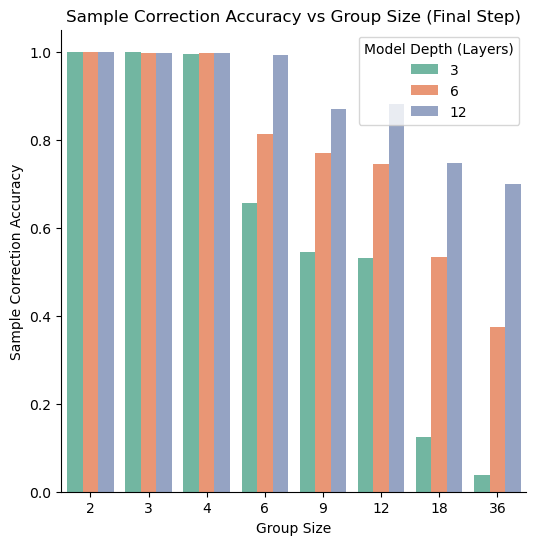

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

final_step_df = mem_eval_syn_df.query("step == 1000000 and train_sample_num == 4096")
plt.figure(figsize=(6, 6))
sns.barplot(data=final_step_df, x="group_size", y="bitgroup_mem_ratio", hue="DiT_nlayer", palette="Set2")
plt.xlabel("Group Size")
plt.ylabel("Sample Correction Accuracy")
plt.title("Sample Correction Accuracy vs Group Size (Final Step)")
plt.legend(title="Model Depth (Layers)")
plt.show()

### Eval Across dataset scales

In [16]:
def add_baseline_lines(x_unique, baseline_dict, color='k', linestyle='--', linewidth=2, alpha=0.7, label='Baseline', ax=None):
    if ax is None:
        ax = plt.gca()
    # Add baseline dashed lines
    group_sizes = sorted(x_unique)
    baseline_values = [baseline_dict[gs] for gs in group_sizes]
    x_positions = range(len(group_sizes))
    
    # Plot flat horizontal lines for each bar position
    for j, (x_pos, baseline_val) in enumerate(zip(x_positions, baseline_values)):
        ax.hlines(y=baseline_val, xmin=x_pos-0.4, xmax=x_pos+0.4,
                   color=color, linestyle=linestyle, linewidth=linewidth, alpha=alpha, label=None)
        # plt.axhline(y=baseline_val, xmin=x_pos/len(group_sizes), xmax=(x_pos+1)/len(group_sizes), 
        # plt.axhline(y=baseline_val, xmin=x_pos-0.4, xmax=x_pos+0.4,
        #            color=color, linestyle=linestyle, linewidth=linewidth, alpha=alpha, label=None)
    
    # Add a legend entry for baseline
    ax.plot([], [], linestyle=linestyle, color=color,
        linewidth=linewidth, alpha=alpha, label=label)


def add_baseline_lines_per_bar(x_unique, baseline_dict, color='k', linestyle='--', linewidth=2, alpha=0.7, label='Baseline', ax=None):
    if ax is None:
        ax = plt.gca()
    # Add baseline dashed lines
    group_sizes = sorted(x_unique)
    baseline_values = [baseline_dict[gs] for gs in group_sizes]
    x_positions = range(len(group_sizes))
    
    # Plot flat horizontal lines for each bar position
    for j, (x_pos, baseline_vals) in enumerate(zip(x_positions, baseline_values)):
        for k, baseline_val in enumerate(baseline_vals):
            xmin = x_pos - 0.4 + k * 0.8 / len(baseline_vals)
            xmax = x_pos - 0.4 + (k+1) * 0.8 / len(baseline_vals)
            ax.hlines(y=baseline_val, xmin=xmin, xmax=xmax,
                   color=color, linestyle=linestyle, linewidth=linewidth, alpha=alpha, label=None)
        # plt.axhline(y=baseline_val, xmin=x_pos/len(group_sizes), xmax=(x_pos+1)/len(group_sizes), 
        # plt.axhline(y=baseline_val, xmin=x_pos-0.4, xmax=x_pos+0.4,
        #            color=color, linestyle=linestyle, linewidth=linewidth, alpha=alpha, label=None)
    
    # Add a legend entry for baseline
    ax.plot([], [], linestyle=linestyle, color=color,
        linewidth=linewidth, alpha=alpha, label=label)


In [5]:
def pergroup_parity_acc_baseline(G, D=36):
    return (1/2)

def sample_corr_baseline(G, D=36):
    return (1/2)**(D//G)

def bitgroup_mem_ratio_groundtruth_baseline(G, N=4096, D=36):
    return min(1.0, N * (D//G) / (2 ** (G-1)))

def bitgroup_mem_ratio_rand_baseline(G, N=4096, D=36):
    return min(N * (D//G), 2 ** (G-1)) / 2 ** G

def sample_mem_ratio_groundtruth_baseline(G, N=4096, D=36):
    return N / (2 ** (G-1)) ** (D // G)

def sample_mem_ratio_rand_baseline(G, N=4096, D=36):
    return N / 2 ** D

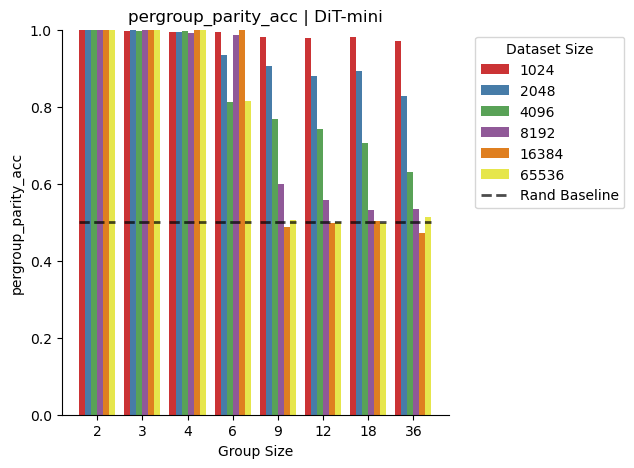

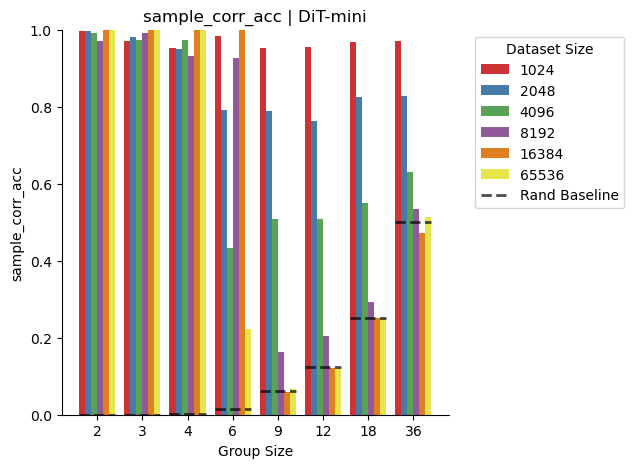

In [13]:
from circuit_toolkit.plot_utils import saveallforms
figdir = "/n/home12/binxuwang/Github/DiffusionAttnConsistency/figures/synopsis"

# Define baseline dictionary mapping group size to baseline values
baseline_dict = {
    "pergroup_parity_acc": {G: pergroup_parity_acc_baseline(G) for G in [2, 3, 4, 6, 9, 12, 18, 36]},
    # "bitgroup_mem_ratio": {G: bitgroup_mem_ratio_baseline(G) for G in [2, 3, 4, 6, 9, 12, 18, 36]},
    "sample_corr_acc": {G: sample_corr_baseline(G) for G in [2, 3, 4, 6, 9, 12, 18, 36]},
    # "sample_mem_ratio": {G: sample_mem_ratio_baseline(G) for G in [2, 3, 4, 6, 9, 12, 18, 36]},
}

final_step_df = mem_eval_syn_df.query("step == 1000000 and DiT_nlayer == 6")

for i, metric in enumerate(["pergroup_parity_acc", "sample_corr_acc", ]):
    plt.figure(figsize=(5, 5))
    sns.barplot(data=final_step_df, x="group_size", y=metric, hue="train_sample_num", palette="Set1")
    add_baseline_lines(final_step_df.group_size.unique(), 
                       baseline_dict[metric], color='k', linestyle='--', linewidth=2, alpha=0.7, label='Rand Baseline')
    plt.ylim(0, 1)
    plt.xlabel("Group Size")
    plt.ylabel(metric)
    plt.title(f"{metric} | DiT-mini")
    plt.legend(title="Dataset Size", bbox_to_anchor=(1.05, 1), loc='upper left')
    # plt.tight_layout()
    saveallforms(figdir, f"DiT_parity_eval_metrics_{metric}_DiT_mini_N_cmp", plt.gcf())
    plt.show()


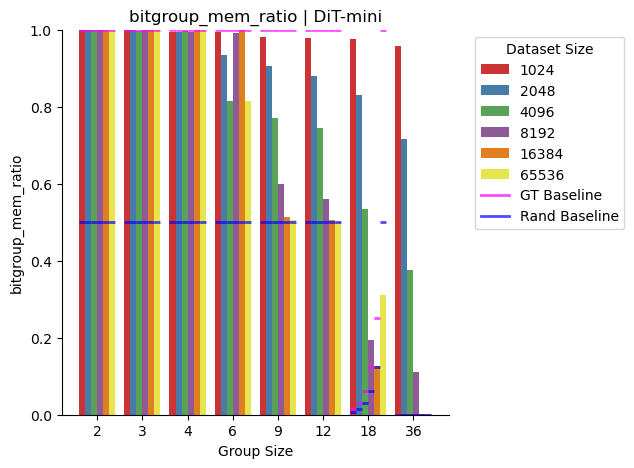

In [18]:
metric = "bitgroup_mem_ratio"
final_step_df = mem_eval_syn_df.query("step == 1000000 and DiT_nlayer == 6")
group_sizes = sorted(final_step_df.group_size.unique())
train_sample_nums = sorted(final_step_df.train_sample_num.unique())
plt.figure(figsize=(5, 5))
ax = sns.barplot(data=final_step_df, x="group_size", y=metric, hue="train_sample_num", palette="Set1")
add_baseline_lines_per_bar(group_sizes, 
                    {G: [bitgroup_mem_ratio_groundtruth_baseline(G, N=N) for N in train_sample_nums] for G in group_sizes}, 
                    color='magenta', linestyle='-', linewidth=2, alpha=0.7, label='GT Baseline')
add_baseline_lines_per_bar(group_sizes, 
                    {G: [bitgroup_mem_ratio_rand_baseline(G, N=N) for N in train_sample_nums] for G in group_sizes}, 
                    color='b', linestyle='-', linewidth=2, alpha=0.7, label='Rand Baseline')
plt.ylim(0, 1)
plt.xlabel("Group Size")
plt.ylabel(metric)
plt.title(f"{metric} | DiT-mini")
plt.legend(title="Dataset Size", bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
saveallforms(figdir, f"DiT_parity_eval_metrics_{metric}_DiT_mini_N_cmp", plt.gcf())
plt.show()

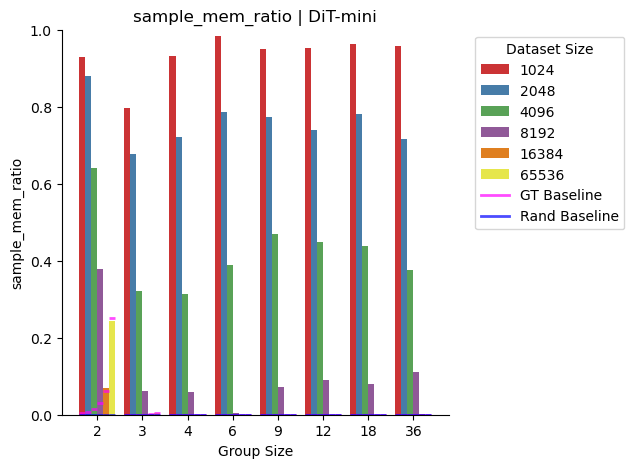

In [21]:
metric = "sample_mem_ratio"
group_sizes = sorted(final_step_df.group_size.unique())
plt.figure(figsize=(5, 5))
ax = sns.barplot(data=final_step_df, x="group_size", y=metric, hue="train_sample_num", palette="Set1")
add_baseline_lines_per_bar(group_sizes, 
                    {G: [sample_mem_ratio_groundtruth_baseline(G, N=N) for N in train_sample_nums] for G in group_sizes}, 
                    color='magenta', linestyle='-', linewidth=2, alpha=0.7, label='GT Baseline')
add_baseline_lines_per_bar(group_sizes, 
                    {G: [sample_mem_ratio_rand_baseline(G, N=N) for N in train_sample_nums] for G in group_sizes}, 
                    color='b', linestyle='-', linewidth=2, alpha=0.7, label='Rand Baseline')
plt.ylim(0, 1)
plt.xlabel("Group Size")
plt.ylabel(metric)
plt.title(f"{metric} | DiT-mini")
plt.legend(title="Dataset Size", bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
saveallforms(figdir, f"DiT_parity_eval_metrics_{metric}_DiT_mini_N_cmp", plt.gcf())
plt.show()

### Demo overlay

In [26]:
palette

[(0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 (0.5529411764705883, 0.6274509803921569, 0.796078431372549)]

In [28]:
palette[0]

(0.4, 0.7607843137254902, 0.6470588235294118)

In [34]:
palette*8

[(0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
 (0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
 (0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
 (0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
 (0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
 (0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 (0.5529411764705883, 0.

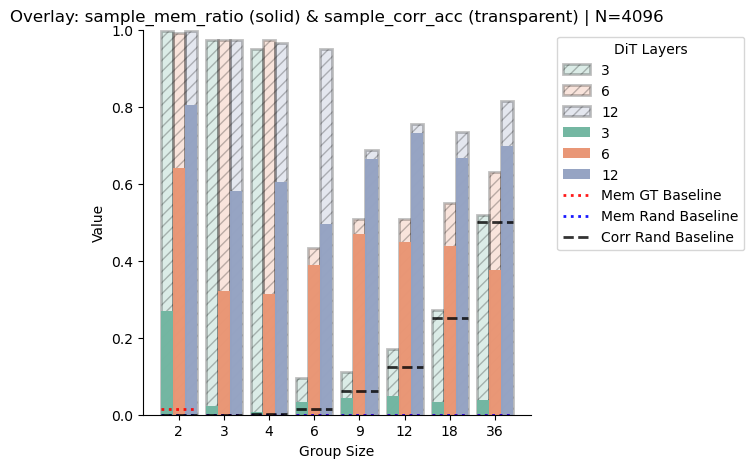

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
final_step_df = mem_eval_syn_df.query("step == 1000000 and train_sample_num == 4096")
# Combine the two metrics into one long-form DataFrame
df_long = pd.melt(
    final_step_df,
    id_vars=["group_size", "DiT_nlayer"],
    value_vars=["sample_mem_ratio", "sample_corr_acc"],
    var_name="metric",
    value_name="value"
)

# Make palette per layer
palette = sns.color_palette("Set2", df_long["DiT_nlayer"].nunique())

fig, ax = plt.subplots(figsize=(5, 5))
# Overlay sample_corr_acc as outline bars
sns.barplot(
    data=df_long[(df_long.metric == "sample_corr_acc")],
    x="group_size", y="value", hue="DiT_nlayer",
    palette=palette, alpha=0.25, edgecolor="black", 
    linewidth=2, dodge=True, ax=ax
)
# Apply stripes to all bars
for patch in ax.patches:
    patch.set_hatch('///')        # diagonal stripes
    # patch.set_edgecolor(patch.get_facecolor())  # keep bar color on edges
    # patch.set_facecolor('none')   # face transparent so hatch is visible
    # patch.set_linewidth(0)        # optional: no outline width
# Plot sample_mem_ratio as filled bars
sns.barplot(
    data=df_long[df_long.metric == "sample_mem_ratio"],
    x="group_size", y="value", hue="DiT_nlayer",
    palette=palette, alpha=0.99, ax=ax, dodge=True
)
# Baselines
add_baseline_lines(
    sorted(final_step_df.group_size.unique()),
    {G: sample_mem_ratio_groundtruth_baseline(G) for G in group_sizes},
    color='r', linestyle=':', linewidth=2, alpha=0.9, label='Mem GT Baseline', ax=ax
)
add_baseline_lines(
    sorted(final_step_df.group_size.unique()),
    {G: sample_mem_ratio_rand_baseline(G) for G in group_sizes},
    color='b', linestyle=':', linewidth=2, alpha=0.9, label='Mem Rand Baseline', ax=ax
)
add_baseline_lines(
    sorted(final_step_df.group_size.unique()),
    {G: sample_corr_baseline(G) for G in group_sizes},
    color='k', linestyle='--', linewidth=2, alpha=0.8, label='Corr Rand Baseline', ax=ax
)

# Cosmetics
ax.set_ylim(0, 1)
ax.set_xlabel("Group Size")
ax.set_ylabel("Value")
ax.set_title("Overlay: sample_mem_ratio (solid) & sample_corr_acc (transparent) | N=4096")

# Legend: keep only one hue legend
handles, labels = ax.get_legend_handles_labels()
# ax.legend(handles[:len(palette)], labels[:len(palette)], title="DiT Layers", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.legend(handles[:], labels[:], title="DiT Layers", bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
saveallforms(figdir, f"DiT_parity_eval_metrics_overlay_sample_mem_ratio_over_acc_N4096", fig)
plt.show()

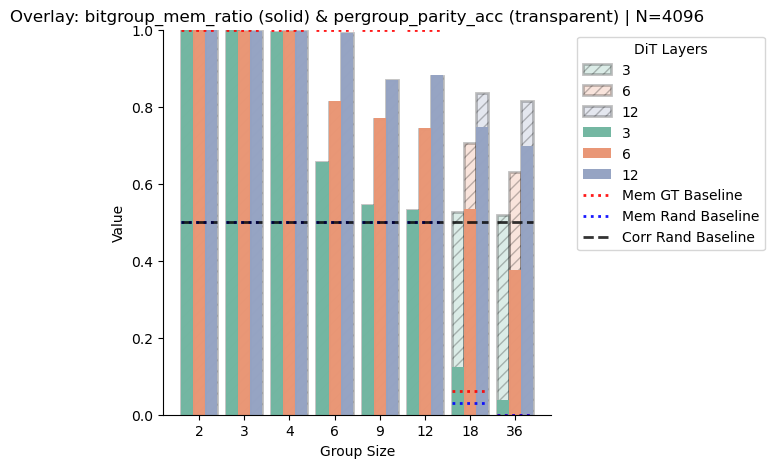

In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
final_step_df = mem_eval_syn_df.query("step == 1000000 and train_sample_num == 4096")
# Combine the two metrics into one long-form DataFrame
df_long = pd.melt(
    final_step_df,
    id_vars=["group_size", "DiT_nlayer"],
    value_vars=["pergroup_parity_acc", "bitgroup_mem_ratio"],
    var_name="metric",
    value_name="value"
)

# Make palette per layer
palette = sns.color_palette("Set2", df_long["DiT_nlayer"].nunique())

fig, ax = plt.subplots(figsize=(5, 5))
# Overlay sample_corr_acc as outline bars
sns.barplot(
    data=df_long[(df_long.metric == "pergroup_parity_acc")],
    x="group_size", y="value", hue="DiT_nlayer",
    palette=palette, alpha=0.25, edgecolor="black", 
    linewidth=2, dodge=True, ax=ax
)
# Apply stripes to all bars
for patch in ax.patches:
    patch.set_hatch('///')        # diagonal stripes
    # patch.set_edgecolor(patch.get_facecolor())  # keep bar color on edges
    # patch.set_facecolor('none')   # face transparent so hatch is visible
    # patch.set_linewidth(0)        # optional: no outline width
# Plot sample_mem_ratio as filled bars
sns.barplot(
    data=df_long[df_long.metric == "bitgroup_mem_ratio"],
    x="group_size", y="value", hue="DiT_nlayer",
    palette=palette, alpha=0.99, ax=ax, dodge=True
)
# Baselines
add_baseline_lines(
    sorted(final_step_df.group_size.unique()),
    {G: bitgroup_mem_ratio_groundtruth_baseline(G) for G in group_sizes},
    color='r', linestyle=':', linewidth=2, alpha=0.9, label='Mem GT Baseline', ax=ax
)
add_baseline_lines(
    sorted(final_step_df.group_size.unique()),
    {G: bitgroup_mem_ratio_rand_baseline(G) for G in group_sizes},
    color='b', linestyle=':', linewidth=2, alpha=0.9, label='Mem Rand Baseline', ax=ax
)
add_baseline_lines(
    sorted(final_step_df.group_size.unique()),
    {G: pergroup_parity_acc_baseline(G) for G in group_sizes},
    color='k', linestyle='--', linewidth=2, alpha=0.8, label='Corr Rand Baseline', ax=ax
)

# Cosmetics
ax.set_ylim(0, 1)
ax.set_xlabel("Group Size")
ax.set_ylabel("Value")
ax.set_title("Overlay: bitgroup_mem_ratio (solid) & pergroup_parity_acc (transparent) | N=4096")

# Legend: keep only one hue legend
handles, labels = ax.get_legend_handles_labels()
# ax.legend(handles[:len(palette)], labels[:len(palette)], title="DiT Layers", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.legend(handles[:], labels[:], title="DiT Layers", bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
saveallforms(figdir, f"DiT_parity_eval_metrics_overlay_bitgroup_mem_ratio_over_acc_N4096", fig)
plt.show()

### Dataset size cmp

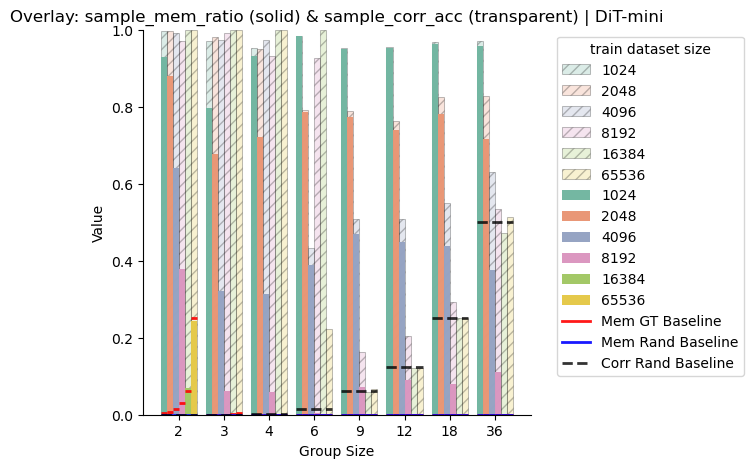

In [57]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
final_step_df = mem_eval_syn_df.query("step == 1000000 and DiT_nlayer == 6")
# Combine the two metrics into one long-form DataFrame
df_long = pd.melt(
    final_step_df,
    id_vars=["group_size", "train_sample_num"],
    value_vars=["sample_mem_ratio", "sample_corr_acc"],
    var_name="metric",
    value_name="value"
)

# Make palette per layer
train_sample_nums = sorted(final_step_df.train_sample_num.unique())
palette = sns.color_palette("Set2", df_long["train_sample_num"].nunique())

fig, ax = plt.subplots(figsize=(5, 5))
# Overlay sample_corr_acc as outline bars
sns.barplot(
    data=df_long[(df_long.metric == "sample_corr_acc")],
    x="group_size", y="value", hue="train_sample_num",
    palette=palette, alpha=0.25, edgecolor="black", 
    linewidth=.75, dodge=True, ax=ax
)
# Apply stripes to all bars
for patch in ax.patches:
    patch.set_hatch('///')        # diagonal stripes
    # patch.set_edgecolor(patch.get_facecolor())  # keep bar color on edges
    # patch.set_facecolor('none')   # face transparent so hatch is visible
    # patch.set_linewidth(0)        # optional: no outline width
# Plot sample_mem_ratio as filled bars
sns.barplot(
    data=df_long[df_long.metric == "sample_mem_ratio"],
    x="group_size", y="value", hue="train_sample_num",
    palette=palette, alpha=0.99, ax=ax, dodge=True
)
# Baselines
add_baseline_lines_per_bar(
    sorted(final_step_df.group_size.unique()),
    {G: [sample_mem_ratio_groundtruth_baseline(G, N=N) for N in train_sample_nums] for G in group_sizes},
    color='r', linestyle='-', linewidth=2, alpha=0.9, label='Mem GT Baseline', ax=ax
)
add_baseline_lines_per_bar(
    sorted(final_step_df.group_size.unique()),
    {G: [sample_mem_ratio_rand_baseline(G, N=N) for N in train_sample_nums] for G in group_sizes},
    color='b', linestyle='-', linewidth=2, alpha=0.9, label='Mem Rand Baseline', ax=ax
)
add_baseline_lines(
    sorted(final_step_df.group_size.unique()),
    {G: sample_corr_baseline(G) for G in group_sizes},
    color='k', linestyle='--', linewidth=2, alpha=0.8, label='Corr Rand Baseline', ax=ax
)

# Cosmetics
ax.set_ylim(0, 1)
ax.set_xlabel("Group Size")
ax.set_ylabel("Value")
ax.set_title("Overlay: sample_mem_ratio (solid) & sample_corr_acc (transparent) | DiT-mini")

# Legend: keep only one hue legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:], labels[:], title="train dataset size", bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
saveallforms(figdir, f"DiT_parity_eval_metrics_overlay_sample_mem_ratio_over_acc_DiT_mini_N_cmp", fig)
plt.show()

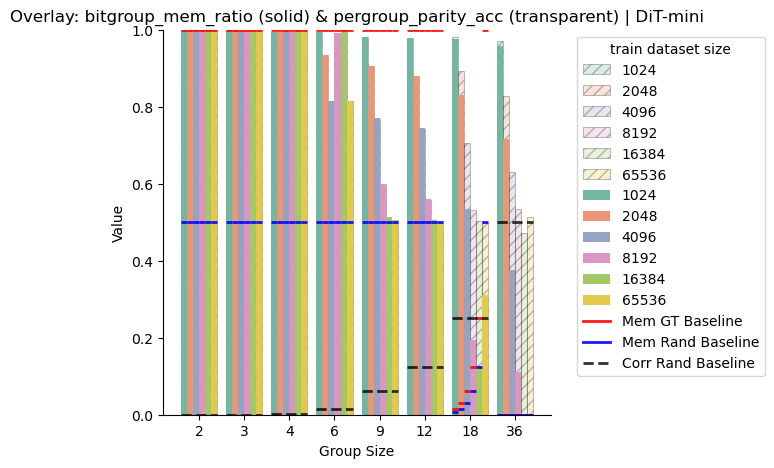

In [56]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
final_step_df = mem_eval_syn_df.query("step == 1000000 and DiT_nlayer == 6")
# Combine the two metrics into one long-form DataFrame
df_long = pd.melt(
    final_step_df,
    id_vars=["group_size", "train_sample_num"],
    value_vars=["pergroup_parity_acc", "bitgroup_mem_ratio"],
    var_name="metric",
    value_name="value"
)

# Make palette per layer
train_sample_nums = sorted(final_step_df.train_sample_num.unique())
palette = sns.color_palette("Set2", df_long["train_sample_num"].nunique())

fig, ax = plt.subplots(figsize=(5, 5))
# Overlay sample_corr_acc as outline bars
sns.barplot(
    data=df_long[(df_long.metric == "pergroup_parity_acc")],
    x="group_size", y="value", hue="train_sample_num",
    palette=palette, alpha=0.25, edgecolor="black", 
    linewidth=.75, dodge=True, ax=ax
)
# Apply stripes to all bars
for patch in ax.patches:
    patch.set_hatch('///')        # diagonal stripes
    # patch.set_edgecolor(patch.get_facecolor())  # keep bar color on edges
    # patch.set_facecolor('none')   # face transparent so hatch is visible
    # patch.set_linewidth(0)        # optional: no outline width
# Plot sample_mem_ratio as filled bars
sns.barplot(
    data=df_long[df_long.metric == "bitgroup_mem_ratio"],
    x="group_size", y="value", hue="train_sample_num",
    palette=palette, alpha=0.99, ax=ax, dodge=True
)
# Baselines
add_baseline_lines_per_bar(
    sorted(final_step_df.group_size.unique()),
    {G: [bitgroup_mem_ratio_groundtruth_baseline(G, N=N) for N in train_sample_nums] for G in group_sizes},
    color='r', linestyle='-', linewidth=2, alpha=0.9, label='Mem GT Baseline', ax=ax
)
add_baseline_lines_per_bar(
    sorted(final_step_df.group_size.unique()),
    {G: [bitgroup_mem_ratio_rand_baseline(G, N=N) for N in train_sample_nums] for G in group_sizes},
    color='b', linestyle='-', linewidth=2, alpha=0.9, label='Mem Rand Baseline', ax=ax
)
add_baseline_lines(
    sorted(final_step_df.group_size.unique()),
    {G: sample_corr_baseline(G) for G in group_sizes},
    color='k', linestyle='--', linewidth=2, alpha=0.8, label='Corr Rand Baseline', ax=ax
)

# Cosmetics
ax.set_ylim(0, 1)
ax.set_xlabel("Group Size")
ax.set_ylabel("Value")
ax.set_title("Overlay: bitgroup_mem_ratio (solid) & pergroup_parity_acc (transparent) | DiT-mini")

# Legend: keep only one hue legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:], labels[:], title="train dataset size", bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
saveallforms(figdir, f"DiT_parity_eval_metrics_overlay_bitgroup_mem_ratio_over_acc_DiT_mini_N_cmp", fig)
plt.show()

### Show example

In [29]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch as th
# Load the training data tensor


In [33]:
saveroot = "/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionParityLearning"
exp_name = "DiT_mini_parity_N4096_D36_G6_even"
train_datatsr = th.load(join(saveroot, exp_name, "training_data_tsr.pt"), weights_only=False)
sample_tsr = th.load(join(saveroot, exp_name, "samples", "samples_epoch_1000000.pt"), weights_only=False)
# !ls $saveroot/$exp_name/samples

In [34]:
train_datatsr.shape

torch.Size([4096, 1, 6, 6])

In [35]:
sample_tsr.shape

torch.Size([2048, 1, 6, 6])

In [43]:
from circuit_toolkit.plot_utils import to_imgrid, show_imgrid
from PIL import Image

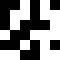

In [51]:
to_imgrid(train_datatsr[0,]).resize((60, 60), 
    resample=Image.Resampling.NEAREST)

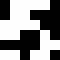

In [72]:
to_imgrid(sample_tsr[7,]).resize((60, 60), 
    resample=Image.Resampling.NEAREST)

In [63]:
compute_membership_counts(train_datatsr.flatten(start_dim=1), sample_tsr[1:2].flatten(start_dim=1).cpu(), 6)

{'sample_mem_num': 0,
 'sample_mem_ratio': 0.0,
 'bitgroup_mem_num': 4,
 'bitgroup_mem_ratio': 0.6666666666666666}

In [65]:
train_datatsr.device

device(type='cpu')

In [67]:
train_group_codes

tensor([-63., -57., -53., -51., -45., -43., -39., -33., -29., -27., -23., -17.,
        -15.,  -9.,  -5.,  -3.,   3.,   5.,   9.,  15.,  17.,  23.,  27.,  29.,
         33.,  39.,  43.,  45.,  51.,  53.,  57.,  63.])

In [68]:
gw

tensor([ 1,  2,  4,  8, 16, 32])

In [71]:
gw = 1 << th.arange(6, device=train_datatsr.device, dtype=th.long)
BG_train = (train_datatsr>0).flatten(start_dim=1).view(-1, 6).cpu()
BG_gen   = (sample_tsr[7:8]>0).flatten(start_dim=1).view(-1, 6).cpu()
train_group_codes = (BG_train * gw).sum(dim=1).unique()
gen_group_codes   = (BG_gen   * gw).sum(dim=1)
th.isin(gen_group_codes, train_group_codes)

tensor([ True,  True,  True, False,  True,  True])

In [27]:
!ls "/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionParityLearning"

cluster_logs			     DiT_nano_parity_N4096_D36_G6_even
DiT_B_parity_N4096_D36_G12_even      DiT_nano_parity_N4096_D36_G9_even
DiT_B_parity_N4096_D36_G18_even      DiT_S_parity_N4096_D36_G12_even
DiT_B_parity_N4096_D36_G2_even	     DiT_S_parity_N4096_D36_G18_even
DiT_B_parity_N4096_D36_G36_even      DiT_S_parity_N4096_D36_G2_even
DiT_B_parity_N4096_D36_G3_even	     DiT_S_parity_N4096_D36_G36_even
DiT_B_parity_N4096_D36_G4_even	     DiT_S_parity_N4096_D36_G3_even
DiT_B_parity_N4096_D36_G6_even	     DiT_S_parity_N4096_D36_G4_even
DiT_B_parity_N4096_D36_G9_even	     DiT_S_parity_N4096_D36_G6_even
DiT_mini_parity_N1024_D36_G12_even   DiT_S_parity_N4096_D36_G9_even
DiT_mini_parity_N1024_D36_G18_even   GPT_B_parity_N32768_D36_G12_even
DiT_mini_parity_N1024_D36_G2_even    GPT_B_parity_N32768_D36_G18_even
DiT_mini_parity_N1024_D36_G36_even   GPT_B_parity_N32768_D36_G2_even
DiT_mini_parity_N1024_D36_G3_even    GPT_B_parity_N32768_D36_G36_even
DiT_mini_parity_N1024_D36_G4_even    GPT_B_parity_N327

### Example

In [ ]:
import sys
import pandas as pd
from os.path import join
from easydict import EasyDict as edict
import json
sys.path.append("/n/home12/binxuwang/Github/DiffusionAttnConsistency")
from scripts.parity_memorization_eval_cli import evaluate_experiment_memorization

# exp_name = "DiT_mini_parity_N8192_D36_G4_even" 
saveroot = "/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionParityLearning"
mem_eval_syn_col = []
for exp_name in exp_names:
    savedir = join(saveroot, exp_name)
    # Load experiment metadata
    args = edict(json.load(open(f"{savedir}/args.json")))
    config = json.load(open(f"{savedir}/config.json"))
    # Extract experiment parameters
    train_sample_num = args.sample_num
    sample_len = args.sample_len
    group_size = args.group_size
    parity = args.parity
    num_groups = sample_len // group_size
    nlayer = config["depth"]
    nhead = config["num_heads"]
    print(f"Parameters: {train_sample_num} samples, {sample_len} bits per sample, {group_size} bits per group")
    mem_eval_stats_df = evaluate_experiment_memorization(exp_name, incremental=True, skip_completed=True, save_plot=False)
    mem_eval_stats_df["exp_name"] = exp_name
    mem_eval_stats_df["train_sample_num"] = train_sample_num
    # mem_eval_stats_df["sample_len"] = sample_len
    mem_eval_stats_df["group_size"] = group_size
    # mem_eval_stats_df["parity"] = parity
    mem_eval_stats_df["num_groups"] = num_groups
    mem_eval_stats_df["DiT_nlayer"] = nlayer
    mem_eval_stats_df["DiT_nhead"] = nhead
    mem_eval_syn_col.append(mem_eval_stats_df)
    print(f"Evaluated {exp_name}")

mem_eval_syn_df = pd.concat(mem_eval_syn_col, axis=0) # concat all the dataframes
mem_eval_syn_df.to_csv(join(saveroot, "mem_eval_synopsis.csv"), index=False)